#Sales Data Analysis

#Goal is to :
    -> Analyze sales performance, identify top-performing regions,
    -> categories, states, and products, and create visualizations
    -> to gain meaningful business insights from the sales data.

In [3]:
# Importing required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [4]:
df = pd.read_csv("/content/superstore.csv.csv") # Load the sales dataset
df.head()  # Display first 5 records

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


In [5]:
print("Rows and Columns:", df.shape) # Checking the  dataset dimensions
df.info() # To Know column names and data types
df.describe() # This gives the statistical summary

Rows and Columns: (9800, 18)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Row ID         9800 non-null   int64  
 1   Order ID       9800 non-null   object 
 2   Order Date     9800 non-null   object 
 3   Ship Date      9800 non-null   object 
 4   Ship Mode      9800 non-null   object 
 5   Customer ID    9800 non-null   object 
 6   Customer Name  9800 non-null   object 
 7   Segment        9800 non-null   object 
 8   Country        9800 non-null   object 
 9   City           9800 non-null   object 
 10  State          9800 non-null   object 
 11  Postal Code    9789 non-null   float64
 12  Region         9800 non-null   object 
 13  Product ID     9800 non-null   object 
 14  Category       9800 non-null   object 
 15  Sub-Category   9800 non-null   object 
 16  Product Name   9800 non-null   object 
 17  Sales          9800 non

,Row ID,Postal Code,Sales
count,9800.000000,9789.000000,9800.000000
mean,4900.500000,55273.322403,230.769059
std,2829.160653,32041.223413,626.651875
min,1.000000,1040.000000,0.444000
25%,2450.750000,23223.000000,17.248000
50%,4900.500000,58103.000000,54.490000
75%,7350.250000,90008.000000,210.605000
max,9800.000000,99301.000000,22638.480000


In [6]:
# Checking for missing values
df.isnull().sum()

,0
Row ID,0
Order ID,0
Order Date,0
Ship Date,0
Ship Mode,0
Customer ID,0
Customer Name,0
Segment,0
Country,0
City,0


In [7]:
# Handling the missing values in Postal Code
df["Postal Code"] = df["Postal Code"].fillna(df["Postal Code"].mode()[0])

In [8]:
#Finding total sales generated
total_sales = df["Sales"].sum()
print("Total Sales:", total_sales)

Total Sales: 2261536.7827000003


In [9]:
print(df.columns)

Index(['Row ID', 'Order ID', 'Order Date', 'Ship Date', 'Ship Mode',
       'Customer ID', 'Customer Name', 'Segment', 'Country', 'City', 'State',
       'Postal Code', 'Region', 'Product ID', 'Category', 'Sub-Category',
       'Product Name', 'Sales'],
      dtype='object')


In [10]:
# Finding total sales by region
region_sales = df.groupby("Region")["Sales"].sum()
print(region_sales)

Region
Central    492646.9132
East       669518.7260
South      389151.4590
West       710219.6845
Name: Sales, dtype: float64


Category
Furniture          728658.5757
Office Supplies    705422.3340
Technology         827455.8730
Name: Sales, dtype: float64


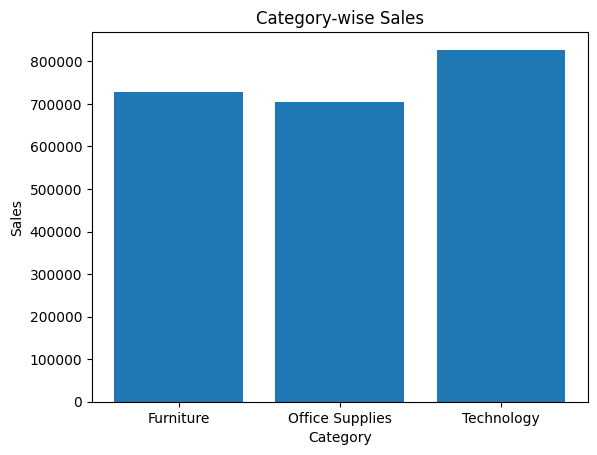

In [11]:
# Finding sales by category
category_sales = df.groupby("Category")["Sales"].sum()
print(category_sales)
# Category-wise Sales
category_sales = df.groupby("Category")["Sales"].sum()
plt.bar(category_sales.index, category_sales.values)
plt.title("Category-wise Sales")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64


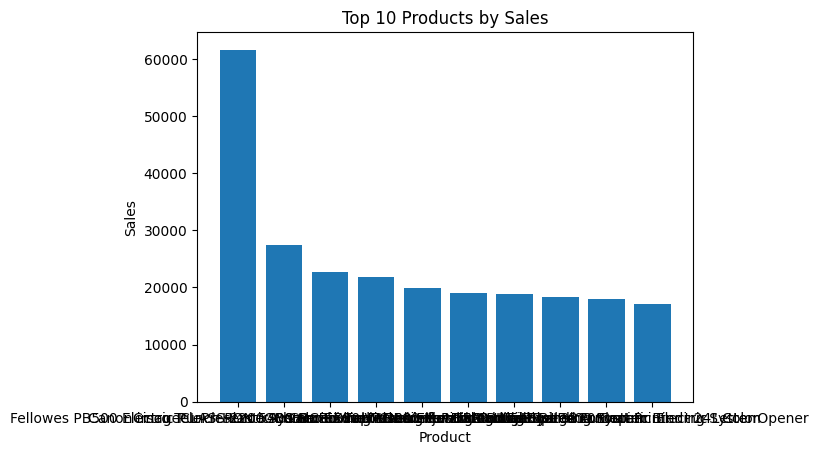

In [12]:
# Goal: Finding top 10 products by sales
product_sales = df.groupby("Product Name")["Sales"].sum()
top_products = product_sales.sort_values(ascending=False).head(10)
print(top_products)
# Top 10 Products by Sales
product_sales = df.groupby("Product Name")["Sales"].sum()
top_products = product_sales.nlargest(10)
plt.bar(top_products.index, top_products.values)
plt.title("Top 10 Products by Sales")
plt.xlabel("Product")
plt.ylabel("Sales")

plt.show()

In [13]:
#Finding sales by state
state_sales = df.groupby("State")["Sales"].sum()
top_states = state_sales.sort_values(ascending=False)
print(top_states.head(10))

State
California      446306.4635
New York        306361.1470
Texas           168572.5322
Washington      135206.8500
Pennsylvania    116276.6500
Florida          88436.5320
Illinois         79236.5170
Michigan         76136.0740
Ohio             75130.3500
Virginia         70636.7200
Name: Sales, dtype: float64


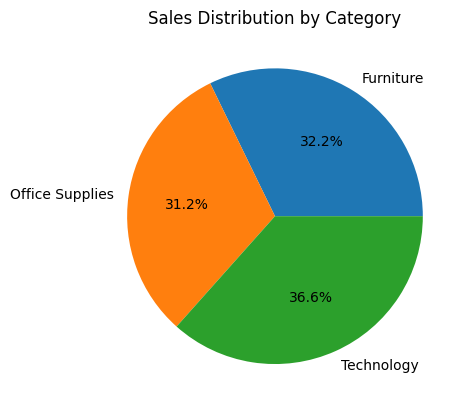

In [14]:
# Sales Distribution by Category
# Category-wise Sales Pie Chart
category_sales = df.groupby("Category")["Sales"].sum()
plt.pie(category_sales.values,labels=category_sales.index,autopct="%1.1f%%")
plt.title("Sales Distribution by Category")
plt.show()

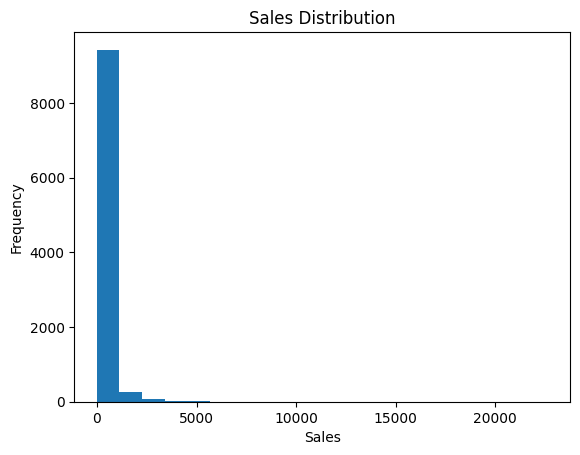

In [15]:
# Distribution of Sales
plt.hist(df["Sales"], bins=20)
plt.title("Sales Distribution")
plt.xlabel("Sales")
plt.ylabel("Frequency")
plt.show()

# Results

1. The **West region** recorded the **highest sales** (710,219.68),followed by the East region (669,518.73).
2. **Technology** was the **best-performing category** with total sales of 827,455.87, indicating strong demand for technology products.
3. The **Canon imageCLASS 2200 Advanced Copier** was the **highest-selling product**, generating sales of 61,599.82.
4. **California** was the **top-performing state** with sales of 446,306.46, followed by New York with 306,361.15.
5. Sales performance varied across regions, categories, and states, highlighting opportunities for targeted business strategies.